In [15]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA_PATH = Path("../../data_processing/dataset.pkl")

with open(DATA_PATH, "rb") as f:
    dataset = pickle.load(f)

# Convenience lists
all_ids = list(dataset.keys())
car_ids = [k for k, (has_car, city, _) in dataset.items() if has_car]
no_car_ids = [k for k, (has_car, city, _) in dataset.items() if not has_car]

print(f"Total homes: {len(all_ids)}")
print(f"With car:    {len(car_ids)}")
print(f"Without car: {len(no_car_ids)}")

Total homes: 73
With car:    14
Without car: 59


In [ ]:
def plot_home(dataid, start=None, end=None, signals=("load", "car1")):
    has_car, city, df = dataset[dataid]
    df = df.loc[start:end]
    fig, axes = plt.subplots(len(signals), 1, figsize=(14, 3 * len(signals)), sharex=True)
    if len(signals) == 1:
        axes = [axes]
    for ax, col in zip(axes, signals):
        ax.plot(df.index, df[col], lw=0.8)
        ax.set_ylabel(col)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[0].set_title(f"Home {dataid}  |  city={city}  |  has_car={has_car}")
    plt.tight_layout()
    plt.show()

def plot_all_signals(dataid, start=None, end=None):
    has_car, city, df = dataset[dataid]
    df = df.loc[start:end]

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    for ax, col in zip(axes[:3], ["load", "non_ev_load", "car1"]):
        ax.plot(df.index, df[col], lw=0.8)
        ax.set_ylabel(f"{col} (kW)")

    axes[3].step(df.index, df["charge_state"], where="post", lw=0.8)
    axes[3].set_yticks([0, 1, 2])
    axes[3].set_ylabel("charge_state")

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    axes[0].set_title(f"Home {dataid}  |  city={city}  |  has_car={has_car}")
    plt.tight_layout()
    plt.show()

In [ ]:
# EV home: all 4 signals
plot_all_signals(car_ids[0], start="2018-07-01", end="2018-07-14")

# Non-EV home: load + non_ev_load
plot_all_signals(no_car_ids[0], start="2018-07-01", end="2018-07-14")

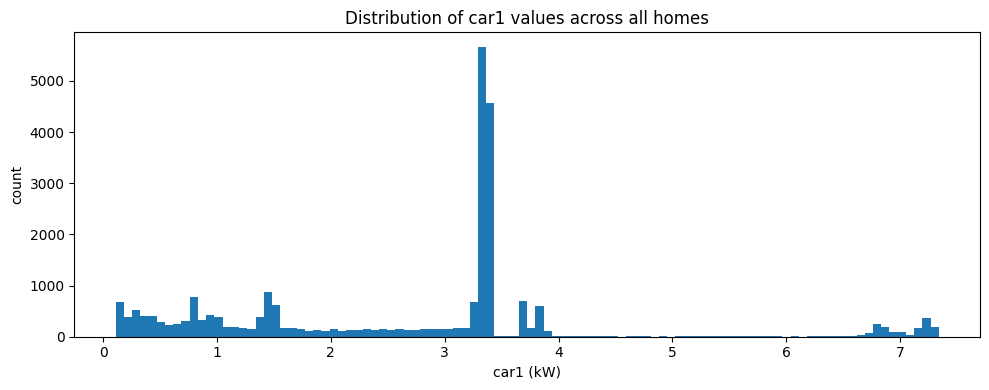

In [20]:
all_car1 = pd.concat(
    df["car1"] for _, (_, _, df) in dataset.items()
).dropna()
all_car1 = all_car1[all_car1 > 0.1]

plt.figure(figsize=(10, 4))
plt.hist(all_car1, bins=100, log=False)
plt.xlabel("car1 (kW)")
plt.ylabel("count")
plt.title("Distribution of car1 values across all homes")
plt.tight_layout()
plt.show()